In [ ]:
# Tomato Mosaic Disease Classification using CNN

Mounted at /content/drive
Dataset extracted successfully!
Dataset folders:
['Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___healthy', 'Tomato_healthy', 'Tomato_Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
Found 1572 images belonging to 2 classes.
Found 392 images belonging to 2 classes.
Training samples: 1572
Validation samples: 392
Class Labels:
{'Tomato__Tomato_mosaic_virus': 0, 'Tomato_healthy': 1}


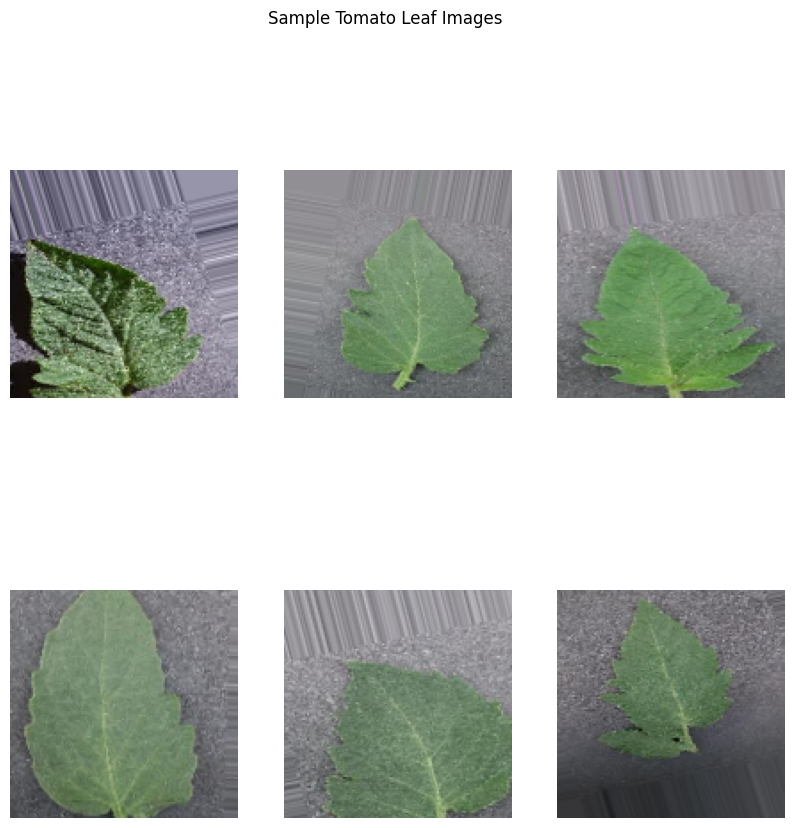

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9141 - loss: 0.5017 - val_accuracy: 0.1888 - val_loss: 27.2744
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 969ms/step - accuracy: 0.9695 - loss: 0.1337 - val_accuracy: 0.1888 - val_loss: 35.6297
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 974ms/step - accuracy: 0.9816 - loss: 0.0563 - val_accuracy: 0.1888 - val_loss: 29.9954
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 959ms/step - accuracy: 0.9860 - loss: 0.0592 - val_accuracy: 0.4694 - val_loss: 14.2953
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 956ms/step - accuracy: 0.9905 - loss: 0.0284 - val_accuracy: 0.4668 - val_loss: 6.0196
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 991ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.6199 - val_loss: 2.0454
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 989ms/step - accuracy: 0.9987 - loss: 0.0058 - val_accuracy: 0.6250 - val_loss: 2.1352
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 948ms/step - accuracy: 0.9885 - loss: 0.0534 - val_acc

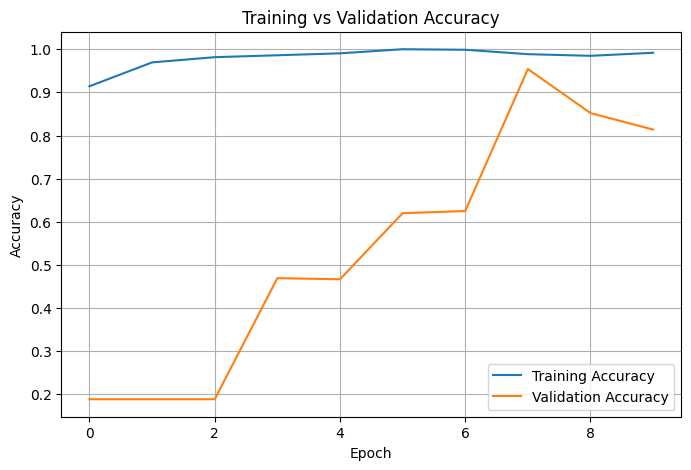

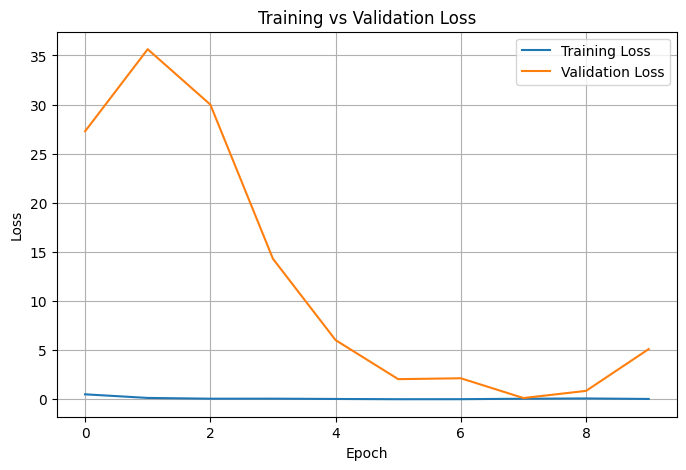

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step


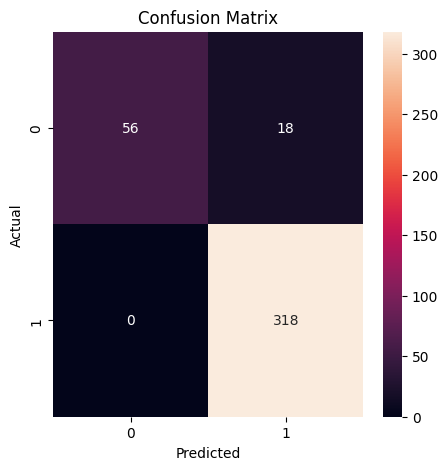

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.76      0.86        74
           1       0.95      1.00      0.97       318

    accuracy                           0.95       392
   macro avg       0.97      0.88      0.92       392
weighted avg       0.96      0.95      0.95       392

Model saved successfully!


In [1]:
# IMPORT LIBRARIES

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import zipfile

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

#  EXTRACT DATASET
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

#  EXPLORE DATASET
dataset_path = '/content/PlantVillage'

print("Dataset folders:")
print(os.listdir(dataset_path))

#  CREATE TOMATO MOSAIC DATASET
source = '/content/PlantVillage'

destination = '/content/tomato_mosaic_dataset'

os.makedirs(destination, exist_ok=True)

classes = [
    'Tomato_healthy',
    'Tomato__Tomato_mosaic_virus'
]

# Copy selected classes
for cls in classes:

    src_path = os.path.join(source, cls)
    dst_path = os.path.join(destination, cls)

    # Avoid copy error if folder already exists
    if not os.path.exists(dst_path):

        shutil.copytree(src_path, dst_path)


#  DATA PREPROCESSING

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator without augmentation
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# LOAD TRAINING DATA
train_generator = train_datagen.flow_from_directory(
    destination,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


#  LOAD VALIDATION DATA
validation_generator = validation_datagen.flow_from_directory(
    destination,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# DATASET INFORMATION
print("Training samples:", train_generator.samples)

print("Validation samples:", validation_generator.samples)

print("Class Labels:")
print(train_generator.class_indices)

# 10. VISUALIZE SAMPLE IMAGES
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.axis('off')

plt.suptitle("Sample Tomato Leaf Images")

plt.show()

#  BUILD CNN MODEL
model = Sequential()

model.add(tf.keras.layers.Input(shape=(128,128,3)))

# First convolution block
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Second convolution block
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Third convolution block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(64, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))


#  COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# EARLY STOPPING
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

#  TRAIN MODEL
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

#  EVALUATE MODEL
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy)

# ACCURACY PLOT
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.grid(True)

plt.show()


#  LOSS PLOT
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.grid(True)

plt.show()


#  CONFUSION MATRIX
Y_pred = model.predict(validation_generator)

y_pred = (Y_pred > 0.5).astype(int)

cm = confusion_matrix(validation_generator.classes, y_pred)

plt.figure(figsize=(5,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()


#  CLASSIFICATION REPORT

print("Classification Report:\n")

print(classification_report(
    validation_generator.classes,
    y_pred
))


# SAVE MODEL
model.save('tomato_mosaic_cnn_model.h5')

print("Model saved successfully!")
